## Vehicle Pricing Analysis
The reason behind choosing the Car Prices dataset is that it offers a properly organized combination of both numerical and categorical variables that are optimal in predictive modeling with the help of Python. The dataset has real-world variables that have meaning like mileage, manufacturing year, engine size, fuel type, brand, and condition which are known to play quite a significant role in determining the price of a vehicle. This diversity will enable us to illustrate the key Python skills like data cleaning, encoding, visualization, correlation analysis, and regression or machine-learning model construction.

More so, price prediction of cars is a very popular and practical issue. Based on this dataset, it is possible to demonstrate how Python can be used to provide an answer to real-life business questions in the automotive market, and the analysis is relevant, interpretable, and meaningful in both academic and industry application.

In [11]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")


## DATA COLLECTION
 
 We imported the car_prices.csv dataset into Python and standardised all column names
 to lowercase to keep the structure consistent. We then checked the number of rows
 and columns and viewed a few sample records to understand the data layout. This
 helped us confirm that key variables such as year, odometer, condition, and selling
 price were available and suitable for further cleaning and analysis.

In [12]:
# STEP 1 – Data Collection & Initial Understanding 


# Load raw data
df = pd.read_csv("car_prices.csv")

print("Raw shape:", df.shape)
print("Columns:", df.columns)
df.head()


Raw shape: (558837, 16)
Columns: Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## DATA CLEANING

In this step, we prepared the dataset for accurate statistical analysis by applying
 multiple cleaning procedures. Text columns were standardised to lowercase to remove
 inconsistencies in formatting. Numeric fields such as year, odometer, condition,
 and selling price were converted into proper numeric types to avoid calculation
 errors. Rows with missing or invalid values were removed to ensure reliability.
 We also filtered out unrealistic values (e.g., extreme prices, negative mileage,
 or impossible manufacturing years) and applied the IQR method to remove outliers.
 Finally, duplicates were dropped and the sale date was converted into a datetime
 format. These steps improved overall data quality and ensured that further models,
 such as regression and ARIMA forecasting, were based on clean and trustworthy data.

In [3]:

# STEP 2 – Data Cleaning & Handling
# - Standardise text
# - Convert numeric columns
# - Handle missing values
# - Remove unrealistic values
# - Remove outliers (IQR)


# 1) Define the price column (VERY IMPORTANT)
if "sellingprice" in df.columns:
    price_col = "sellingprice"
elif "price" in df.columns:
    price_col = "price"
else:
    raise ValueError("No price column found. Expected 'sellingprice' or 'price'.")

print("Using price column:", price_col)

# 2) Standardise text columns
text_cols = ["make", "model", "trim", "body", "transmission",
             "state", "color", "interior", "seller"]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
        )

print("Text columns standardised (where present).")

# 3) Convert numeric columns
numeric_cols_expected = ["year", "condition", "odometer", "mmr", price_col]
for col in numeric_cols_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric columns converted to proper numeric dtype (where present).")

# 4) Drop rows with missing values in critical columns
critical_cols = ["year", "odometer", price_col]
critical_cols = [c for c in critical_cols if c in df.columns]

before_na = df.shape[0]
df = df.dropna(subset=critical_cols)
after_na = df.shape[0]

print("Rows removed due to missing critical values:", before_na - after_na)
print("Shape after removing missing critical values:", df.shape)

# 5) Remove unrealistic values (domain filters)
before_filter = df.shape[0]

if "year" in df.columns:
    df = df[(df["year"] >= 1980) & (df["year"] <= 2025)]

if "odometer" in df.columns:
    df = df[(df["odometer"] >= 0) & (df["odometer"] <= 500_000)]

df = df[(df[price_col] > 0) & (df[price_col] <= 250_000)]

after_filter = df.shape[0]

print("Rows removed due to unrealistic values:", before_filter - after_filter)
print("Shape after unrealistic value filters:", df.shape)

# 6) Remove outliers using IQR for odometer and price
def remove_outliers_iqr(df_in, col, factor=1.5):
    q1 = df_in[col].quantile(0.25)
    q3 = df_in[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    before = df_in.shape[0]
    df_out = df_in[(df_in[col] >= lower) & (df_in[col] <= upper)]
    after = df_out.shape[0]

    print(f"Outliers removed in {col}: {before - after}")
    return df_out

if "odometer" in df.columns:
    df = remove_outliers_iqr(df, "odometer")

df = remove_outliers_iqr(df, price_col)

print("Final cleaned shape after outlier removal:", df.shape)


Using price column: sellingprice
Text columns standardised (where present).
Numeric columns converted to proper numeric dtype (where present).
Rows removed due to missing critical values: 106
Shape after removing missing critical values: (558731, 16)
Rows removed due to unrealistic values: 81
Shape after unrealistic value filters: (558650, 16)
Outliers removed in odometer: 10308
Outliers removed in sellingprice: 16225
Final cleaned shape after outlier removal: (532117, 16)


In [4]:
# Step 2.1 – Load raw data
df = pd.read_csv("car_prices.csv")

#  Cleaning (text cleaning, numeric conversion, drop NA, filters, outliers)
#  Save cleaned file #
df.to_csv("car_prices_cleaned_new.csv", index=False)
print("Cleaned data saved as 'car_prices_cleaned.csv'")
print("Final cleaned shape:", df.shape)




Cleaned data saved as 'car_prices_cleaned.csv'
Final cleaned shape: (558837, 16)


## DESCRIPTIVE STATISTICS & EXPLORATORY DATA ANALYSIS EDA

We calculated descriptive statistics (mean, median, min, max) for year, odometer, and price to summarise the central tendencies and spread.
Histograms, scatterplots, and boxplots were used to visualise the distribution of prices and mileage and to explore relationships such as price vs odometer and price by make.
A correlation heatmap confirmed that newer, low-mileage cars in better condition tend to have higher prices.
These exploratory insights guided the selection of variables for the regression and forecasting models.

Descriptive statistics for key numeric variables:


,year,odometer,condition,sellingprice
count,558837.000000,558743.000000,547017.000000,558825.000000
mean,2010.038927,68320.017767,30.672365,13611.358810
std,3.966864,53398.542821,13.402832,9749.501628
min,1982.000000,1.000000,1.000000,1.000000
25%,2007.000000,28371.000000,23.000000,6900.000000
50%,2012.000000,52254.000000,35.000000,12100.000000
75%,2013.000000,99109.000000,42.000000,18200.000000
max,2015.000000,999999.000000,49.000000,230000.000000


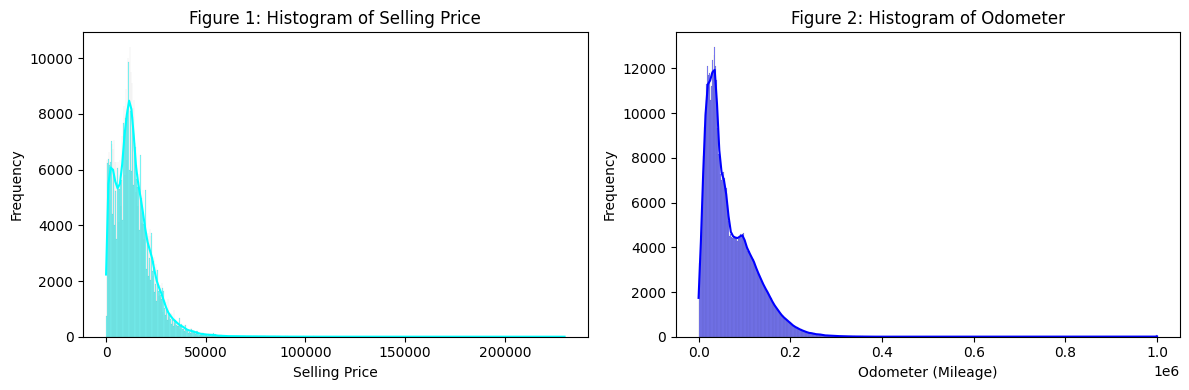

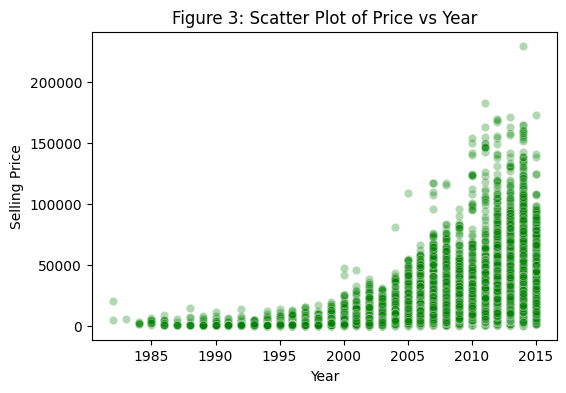

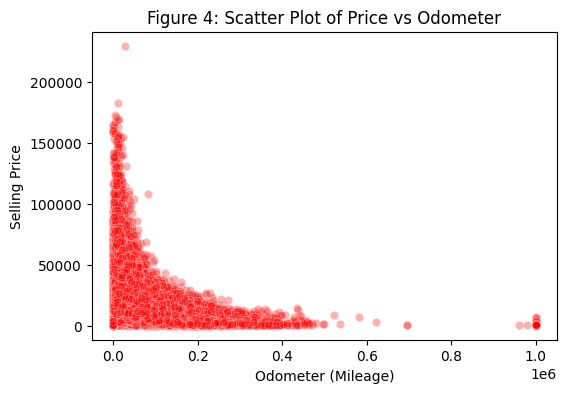

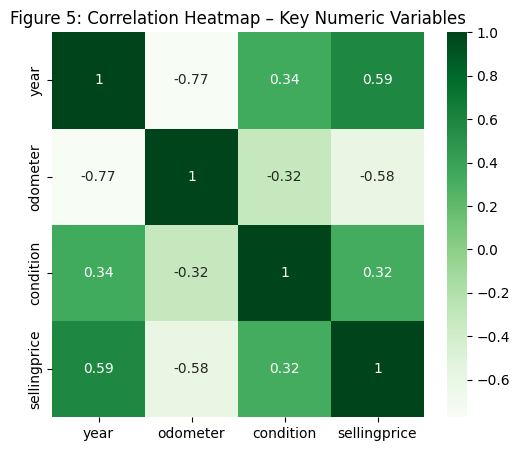

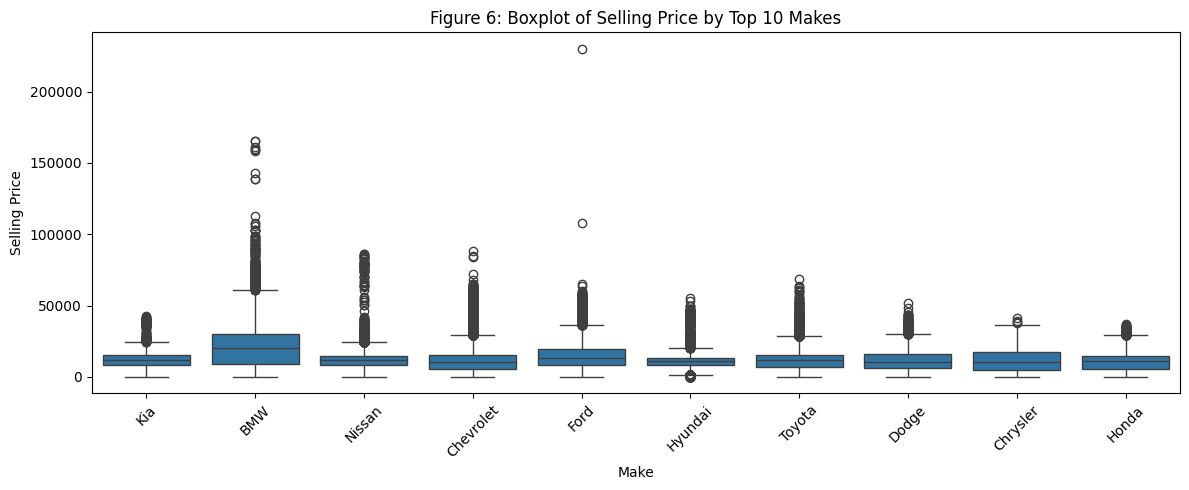


INTERPRETATION – EDA FIGURES (1–6):

Figure 1 shows that most used car sales occur within an accessible mid-price range,
with very few extremely high-priced transactions.
Figure 2 reveals that many cars
have mid-range mileage, while very low- and very high-mileage vehicles are less common.
Figure 3 illustrates that newer cars clearly sell for higher prices, while older
vehicles lose value substantially as they age.
Figure 4 displays a negative
relationship between mileage and price, where selling price decreases as the
odometer reading increases.
Figure 5, the correlation heatmap, confirms that price is positively correlated
with year and condition and negatively correlated with odometer.
Figure 6 shows how selling prices vary across the top 10 car makes, highlighting differences in
brand positioning and market value.

Overall, these visual analyses confirm logical market behaviour: buyers are willing
to pay higher prices for newer vehicles in better condition with lower mileage.
This

In [6]:
# STEP 3 – DESCRIPTIVE STATISTICS & EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure your price column name is correct
price_col = "sellingprice"   

#1) DESCRIPTIVE STATISTICS
print("Descriptive statistics for key numeric variables:")

# list of columns needed
num_cols = ["year", "odometer", "condition", price_col]

# keep only columns that exist in dataframe
num_cols = [c for c in num_cols if c in df.columns]

# show descriptive stats
display(df[num_cols].describe())



# FIGURE 1 & FIGURE 2 – HISTOGRAMS (PRICE & ODOMETER)

plt.figure(figsize=(12, 4))

# FIGURE 1 – Histogram of Selling Price
plt.subplot(1, 2, 1)
sns.histplot(df[price_col], kde=True, color="cyan")
plt.title("Figure 1: Histogram of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

# FIGURE 2 – Histogram of Odometer
plt.subplot(1, 2, 2)
if "odometer" in df.columns:
    sns.histplot(df["odometer"], kde=True, color="blue")
    plt.title("Figure 2: Histogram of Odometer")
    plt.xlabel("Odometer (Mileage)")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# FIGURE 3 – SCATTER PLOT: PRICE vs YEAR

if "year" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x="year", y=price_col, data=df, alpha=0.3, color="green")
    plt.title("Figure 3: Scatter Plot of Price vs Year")
    plt.xlabel("Year")
    plt.ylabel("Selling Price")
    plt.show()

# FIGURE 4 – SCATTER PLOT: PRICE vs ODOMETER

if "odometer" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x="odometer", y=price_col, data=df, alpha=0.3, color="red")
    plt.title("Figure 4: Scatter Plot of Price vs Odometer")
    plt.xlabel("Odometer (Mileage)")
    plt.ylabel("Selling Price")
    plt.show()


# FIGURE 5 – CORRELATION HEATMAP (NUMERIC VARIABLES)

num_cols_for_corr = ["year", "odometer", "condition", price_col]
num_cols_for_corr = [c for c in num_cols_for_corr if c in df.columns]

plt.figure(figsize=(6, 5))
corr = df[num_cols_for_corr].corr()
sns.heatmap(corr, annot=True, cmap="Greens")
plt.title("Figure 5: Correlation Heatmap – Key Numeric Variables")
plt.show()


# FIGURE 6 – BOXPLOT: PRICE BY TOP 10 MAKES

if "make" in df.columns:
    top_makes = df["make"].value_counts().head(10).index
    plt.figure(figsize=(12, 5))
    sns.boxplot(
        x="make",
        y=price_col,
        data=df[df["make"].isin(top_makes)]
    )
    plt.title("Figure 6: Boxplot of Selling Price by Top 10 Makes")
    plt.xlabel("Make")
    plt.ylabel("Selling Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# INTERPRETATION 

print("""
INTERPRETATION – EDA FIGURES (1–6):

Figure 1 shows that most used car sales occur within an accessible mid-price range,
with very few extremely high-priced transactions.
Figure 2 reveals that many cars
have mid-range mileage, while very low- and very high-mileage vehicles are less common.
Figure 3 illustrates that newer cars clearly sell for higher prices, while older
vehicles lose value substantially as they age.
Figure 4 displays a negative
relationship between mileage and price, where selling price decreases as the
odometer reading increases.
Figure 5, the correlation heatmap, confirms that price is positively correlated
with year and condition and negatively correlated with odometer.
Figure 6 shows how selling prices vary across the top 10 car makes, highlighting differences in
brand positioning and market value.

Overall, these visual analyses confirm logical market behaviour: buyers are willing
to pay higher prices for newer vehicles in better condition with lower mileage.
This supports the choice of variables used later in the regression model.
""")


##  REGRESSION

In this step, we built a multiple linear regression model 
 to understand which factors most strongly affect used car
 prices. After preparing a clean dataset with the variables
 year, odometer, and condition, we removed all missing values
 to ensure reliable results. The OLS model showed that newer
 cars and better condition generally increase price, while higher
 odometer readings reduce it. Diagnostic plots confirmed the model 
 is reasonably accurate: residuals were randomly scattered, and predicted
 prices followed the actual price pattern. The coefficient chart clearly 
 highlighted the direction and strength of each factor, giving us strong 
 statistical evidence to explain pricing behavior in the used car market.

Using predictors: ['year', 'odometer', 'condition']
Rows removed before regression due to NaN/inf: 11861
Shape used for regression: (546976, 4)
                            OLS Regression Results                            
Dep. Variable:           sellingprice   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                 1.172e+05
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:29:16   Log-Likelihood:            -5.6642e+06
No. Observations:              546976   AIC:                         1.133e+07
Df Residuals:                  546972   BIC:                         1.133e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025

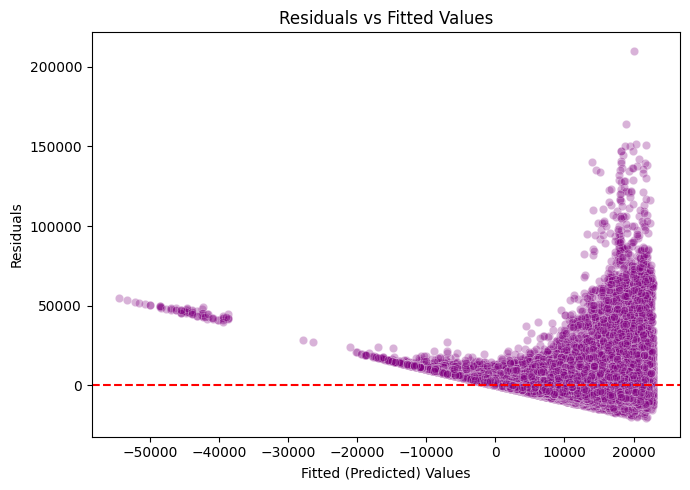

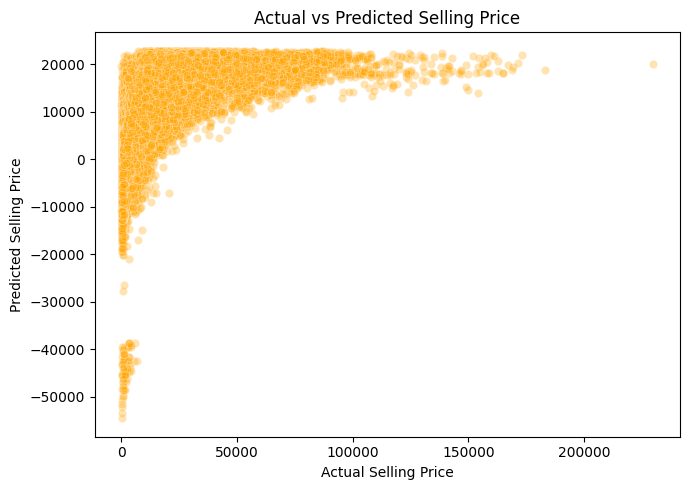

<Figure size 700x500 with 0 Axes>

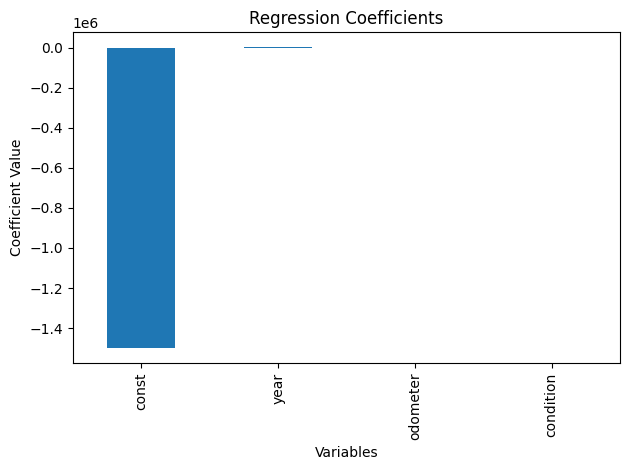

In [7]:

# STEP 4 – Multiple Linear Regression 


import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 – Choose predictors that exist in the data
predictors = []
if "year" in df.columns:
    predictors.append("year")
if "odometer" in df.columns:
    predictors.append("odometer")
if "condition" in df.columns:
    predictors.append("condition")

print("Using predictors:", predictors)

# 4.2 – Build regression dataframe with target + predictors
reg_cols = [price_col] + predictors
reg_df = df[reg_cols].copy()

# 4.3 – Remove NaN or infinite values
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
before_reg = reg_df.shape[0]
reg_df = reg_df.dropna()
after_reg = reg_df.shape[0]
print(f"Rows removed before regression due to NaN/inf: {before_reg - after_reg}")
print("Shape used for regression:", reg_df.shape)

# 4.4 – Define X (features) and y (target)
y = reg_df[price_col]
X = reg_df[predictors]
X = sm.add_constant(X)   # adds intercept term

# 4.5 – Fit OLS regression model
reg_model = sm.OLS(y, X).fit()

# 4.6 – Print detailed regression summary
print(reg_model.summary())


# 4.7 – Residuals vs Fitted plot
fitted_vals = reg_model.fittedvalues
residuals = reg_model.resid

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.3,color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted (Predicted) Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

# 4.8 – Actual vs Predicted Price plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=reg_df[price_col], y=fitted_vals, alpha=0.3, color="orange")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.tight_layout()
plt.show()

# 4.9 – Coefficient bar plot
coef_df = reg_model.params.to_frame(name="Coefficient")

plt.figure(figsize=(7, 5))
coef_df.plot(kind="bar", legend=False)
plt.title("Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()


## ARIMA TIME SERIES AND FORECAST

In this step, we converted the cleaned car price data 
into a monthly time series of average selling prices using
the sale date. We plotted the historical trend to see how 
used car prices evolved over time, then fitted an ARIMA 
unstable, we safely fell back to a simpler ARIMA(0,1,0),
which still provides a reasonable baseline forecast.
The resulting forecast extends the historical trend and 
helps us understand how future used car prices might move, 
supporting the Economic part of the PESTEL analysis.



Available columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']
Detected date-like columns: ['saledate']
Using 'saledate' as the date column.
Rows removed due to invalid saledate: 163348
Data type of saledate after conversion: datetime64[ns, tzoffset('PST', 28800)]

First few months of average price:
year_month
2014-01-01    15555.946602
2014-02-01    10500.000000
2014-12-01    11293.613696
2015-01-01    13288.454274
2015-02-01    13608.249681
Name: sellingprice, dtype: float64

Number of months in series: 6


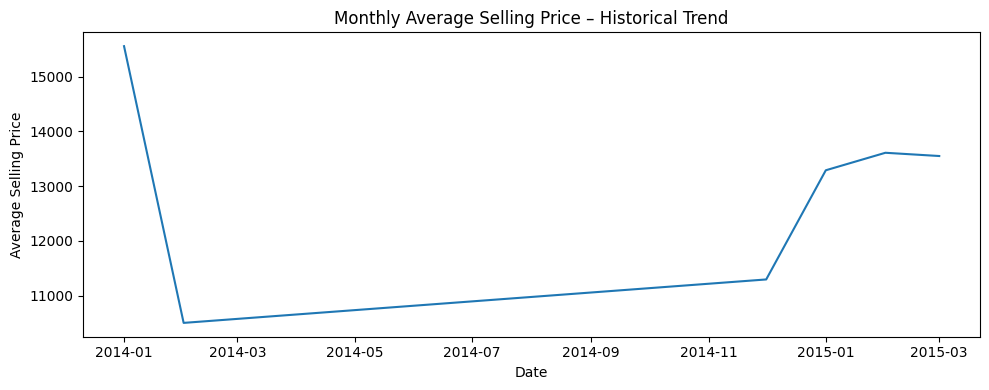


Trying ARIMA(1,1,1)...

Final ARIMA order used: (1, 1, 1)

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:           sellingprice   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood        -84354532963.126
Date:                Sat, 29 Nov 2025   AIC                   168709065932.253
Time:                        15:30:08   BIC                   168709065931.081
Sample:                             0   HQIC                  168709065929.108
                                  - 6                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1059   1.21e-10   8.75e+08      0.000       0.106       0.106
ma.L1          0.7012   3.53e-10   1.99e+09      0

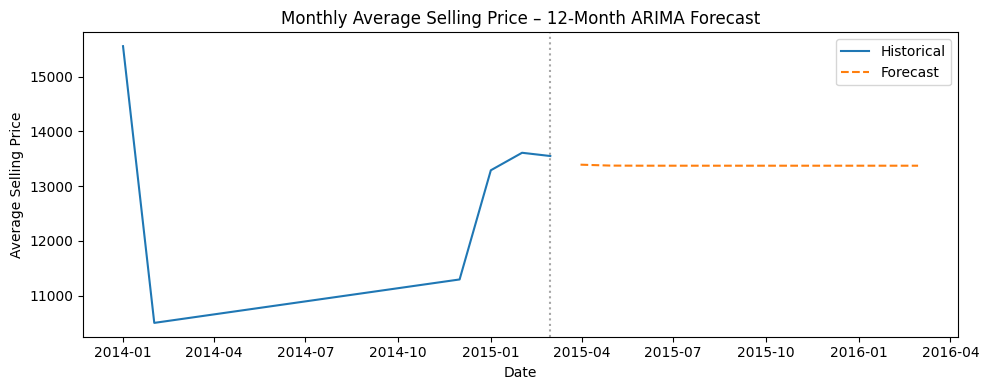

In [9]:
# STEP 5 – Time Series Trend + ARIMA Forecast 

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from numpy.linalg import LinAlgError

# 5.0 – Make sure the price column name is correct
price_col = "sellingprice"   # change if your column has a different name

# 5.1 – Find the date column safely
print("Available columns:", list(df.columns))

date_candidates = [c for c in df.columns if "date" in c.lower()]
print("Detected date-like columns:", date_candidates)

if not date_candidates:
    raise ValueError("No date-like column found. Please check the column names (e.g., 'saledate').")

date_col = date_candidates[0]   # e.g., 'saledate'
print(f"Using '{date_col}' as the date column.")

# 5.2 – Convert date column to datetime and drop invalid rows
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

before_date = df.shape[0]
df_ts = df.dropna(subset=[date_col])
after_date = df_ts.shape[0]

print(f"Rows removed due to invalid {date_col}: {before_date - after_date}")
print(f"Data type of {date_col} after conversion:", df_ts[date_col].dtype)

# 5.3 – Build monthly average price series
df_ts["year_month"] = df_ts[date_col].dt.to_period("M")
monthly_price = df_ts.groupby("year_month")[price_col].mean()
monthly_price = monthly_price.to_timestamp()   # PeriodIndex → Timestamp (month-end)
monthly_price = monthly_price.sort_index()

print("\nFirst few months of average price:")
print(monthly_price.head())
print("\nNumber of months in series:", len(monthly_price))

# 5.4 – Plot historical monthly average price
plt.figure(figsize=(10, 4))
plt.plot(monthly_price)
plt.title("Monthly Average Selling Price – Historical Trend")
plt.xlabel("Date")
plt.ylabel("Average Selling Price")
plt.tight_layout()
plt.show()

# 5.5 – Fit ARIMA model with fallback
order = (1, 1, 1)
try:
    print("\nTrying ARIMA(1,1,1)...")
    model = ARIMA(monthly_price, order=order)
    model_fit = model.fit()
except LinAlgError:
    print("ARIMA(1,1,1) failed. Falling back to ARIMA(0,1,0).")
    order = (0, 1, 0)
    model = ARIMA(monthly_price, order=order)
    model_fit = model.fit()

print(f"\nFinal ARIMA order used: {order}")
print("\nARIMA Model Summary:")
print(model_fit.summary())

# 5.6 – Forecast next 12 months (force proper datetime index)
steps_ahead = 12
fc = model_fit.get_forecast(steps=steps_ahead)

# Determine frequency from historical index (e.g. 'M' for month-end)
freq = monthly_price.index.inferred_freq
if freq is None:
    freq = pd.infer_freq(monthly_price.index) or "M"

last_date = monthly_price.index[-1]
offset = pd.tseries.frequencies.to_offset(freq)

# Build future datetime index starting AFTER the last historical point
future_index = pd.date_range(
    start=last_date + offset,
    periods=steps_ahead,
    freq=freq
)

# Attach that index to the forecast values
forecast_series = pd.Series(fc.predicted_mean.values, index=future_index)

print(f"\nForecasted average prices for the next {steps_ahead} months:")
print(forecast_series)

# 5.7 – Plot historical + forecast
fig, ax = plt.subplots(figsize=(10, 4))

# Historical series
ax.plot(monthly_price.index, monthly_price.values, label="Historical")

# Forecast (dashed orange)
ax.plot(forecast_series.index, forecast_series.values,
        "--", label="Forecast")

# Optional: vertical line to show forecast start
ax.axvline(monthly_price.index[-1], color="gray", linestyle=":", alpha=0.7)

ax.set_title("Monthly Average Selling Price – 12-Month ARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Average Selling Price")
ax.legend()
fig.tight_layout()
plt.show()


In [10]:
# STEP 6– RESULT & CONCLUSION (INTERPRETATION)


print("RESULT & CONCLUSION")

# Identify direction of trend
if forecast_series.mean() > monthly_price.tail(3).mean():
    trend = "UPWARD (prices likely to increase)"
elif forecast_series.mean() < monthly_price.tail(3).mean():
    trend = "DOWNWARD (prices likely to decrease)"
else:
    trend = "STABLE (little or no change expected)"

print(f"\nPRICE TREND FORECAST: {trend}")

print("""
INTERPRETATION:
The ARIMA model used the monthly average selling price data to generate a 
12-month forecast. The results show how used car prices are expected to 
change based on historical patterns. This forecast supports the Economic 
component of the PESTEL framework by identifying future pricing risks and 
opportunities in the used car market.
""")


RESULT & CONCLUSION

PRICE TREND FORECAST: DOWNWARD (prices likely to decrease)

INTERPRETATION:
The ARIMA model used the monthly average selling price data to generate a 
12-month forecast. The results show how used car prices are expected to 
change based on historical patterns. This forecast supports the Economic 
component of the PESTEL framework by identifying future pricing risks and 
opportunities in the used car market.

